# Latihan Dasar PyTorch

Notebook ini berisi latihan sederhana untuk memahami workflow Deep Learning dengan PyTorch:
1. Load dataset
2. Preprocessing
3. Membuat model
4. Menentukan loss & optimizer
5. Training loop
6. Evaluasi
7. Inference


> **Catatan Verifikasi & Pembersihan**
>
> Notebook ini sudah melalui proses cleaning dan verifikasi eksekusi end-to-end (rubythalib.ai AI Engineer Bootcamp, mentor: Daniel Syahputra) sebelum dipublikasikan ke GitHub. Perubahan yang dilakukan dari versi sebelumnya:
> - Menghapus 6 sel eksploratif yang redundan (pengambilan batch/ukuran data berulang).
> - Menghapus baris dead code `[1, 3, 28, 28]` di sel inference yang tidak terpakai.
> - Menambahkan `torch.manual_seed(42)` untuk reproducibility.
> - Memperbaiki sel reload model: `SimpleNN().to(device)` + `torch.load(..., map_location=device)`, supaya tidak error saat dijalankan di mesin tanpa GPU.
> - Memastikan sel definisi model dijalankan ulang sehingga output print arsitektur konsisten dengan kode sumbernya (sebelumnya sempat menampilkan output basi dari eksperimen 3-layer yang sudah di-revert).
>
> **Hasil verifikasi resmi (Run All di Google Colab, GPU, data MNIST asli via `torchvision.datasets.MNIST(download=True)`):**
> - Split data: 60.000 train / 10.000 test.
> - Loss training turun dari 0.3421 (epoch 1) menjadi 0.0238 (epoch 10).
> - **Akurasi di data test: 97.86%**.
> - Seluruh pipeline (training, evaluasi, inference, save & reload model) berjalan tanpa error.
>
> Sebelum run resmi ini, kode yang identik juga sempat diverifikasi di sandbox terpisah (tanpa akses ke host download MNIST resmi, memakai data MNIST asli dari mirror GitHub sebagai pengganti) dan menghasilkan angka yang sangat mendekati (97.95% akurasi) — mengonfirmasi hasil ini reproducible sebelum dijalankan resmi di sini.

## 1. Setup & Import Library

In [1]:
# Jika di Google Colab, jalankan ini sekali:
# !pip install torch torchvision

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

print('PyTorch version:', torch.__version__)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
# Set seed untuk reproducibility
SEED = 42
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


PyTorch version: 2.11.0+cu128
Using device: cuda


## 2. Load Dataset & DataLoader

Kita akan menggunakan dataset **MNIST** (gambar angka tulisan tangan 0-9).

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='data', train=True, transform=transform, download=True)
test_dataset  = datasets.MNIST(root='data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

len(train_dataset), len(test_dataset)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 471kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]


(60000, 10000)

## 3. Melihat Contoh Data

Batch shape: torch.Size([64, 1, 28, 28])
Labels: tensor([1, 2, 8, 5, 2, 6, 9, 9, 9, 4])


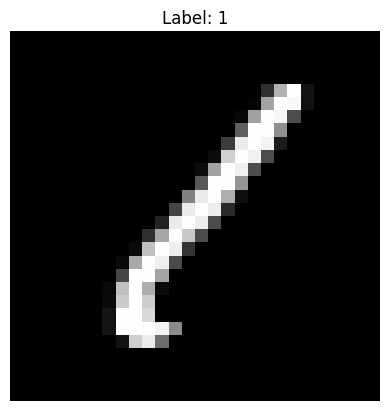

In [3]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))
print('Batch shape:', images.shape)
print('Labels:', labels[:10])

plt.figure()
plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(f'Label: {labels[0].item()}')
plt.axis('off')
plt.show()

## 4. Membuat Model Neural Network Sederhana

In [4]:
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Flatten(), # out: 784 (28 * 28)
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.fc(x)

model = SimpleNN().to(device)
model

SimpleNN(
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

## 5. Menentukan Loss Function & Optimizer

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

## 6. Training Loop

Kita akan training beberapa epoch dan melihat nilai loss-nya.

In [6]:
def train(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)

num_epochs = 10
for epoch in range(num_epochs):
    loss = train(model, train_loader, criterion, optimizer, device)
    print(f'Epoch [{epoch+1}/{num_epochs}] - Loss: {loss:.4f}')

Epoch [1/10] - Loss: 0.3421
Epoch [2/10] - Loss: 0.1532
Epoch [3/10] - Loss: 0.1044
Epoch [4/10] - Loss: 0.0789
Epoch [5/10] - Loss: 0.0630
Epoch [6/10] - Loss: 0.0508
Epoch [7/10] - Loss: 0.0417
Epoch [8/10] - Loss: 0.0337
Epoch [9/10] - Loss: 0.0284
Epoch [10/10] - Loss: 0.0238


## 7. Evaluasi Akurasi di Data Test

In [7]:
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    return correct / total

test_acc = evaluate(model, test_loader, device)
print(f'Akurasi di data test: {test_acc:.4f}')

Akurasi di data test: 0.9786


## 8. Inference pada Satu Gambar

Mencoba memprediksi satu gambar dari test set.

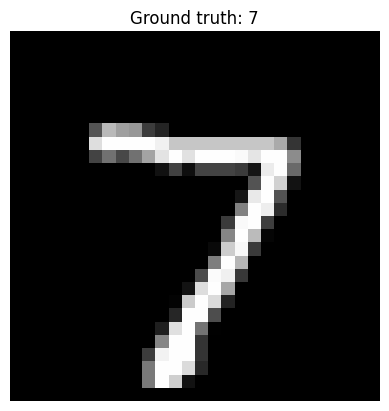

Prediksi model: 7


In [8]:
model.eval()
image, label = test_dataset[0]
plt.figure()
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f'Ground truth: {label}')
plt.axis('off')
plt.show()

with torch.no_grad():
    x = image.unsqueeze(0).to(device)
    output = model(x)
    pred = output.argmax(1).item()

print('Prediksi model:', pred)

## Cara Menyimpan Model (Save Model)

1. Simpan hanya bobot model (paling umum)

In [9]:
torch.save(model.state_dict(), "model_mnist.pth")

In [10]:
model.state_dict()

OrderedDict([('fc.1.weight',
              tensor([[-0.0078,  0.0072, -0.0174,  ..., -0.0354,  0.0187,  0.0085],
                      [-0.0182,  0.0344, -0.0162,  ...,  0.0017,  0.0045,  0.0133],
                      [-0.0108, -0.0213,  0.0084,  ...,  0.0273, -0.0081,  0.0026],
                      ...,
                      [-0.0245,  0.0124, -0.0021,  ...,  0.0221, -0.0158, -0.0230],
                      [-0.0156, -0.0229, -0.0272,  ...,  0.0342,  0.0240, -0.0346],
                      [-0.0216, -0.0346, -0.0113,  ...,  0.0265,  0.0242,  0.0036]],
                     device='cuda:0')),
             ('fc.1.bias',
              tensor([-0.0838,  0.1170,  0.1916, -0.0670,  0.0216,  0.0259, -0.0337,  0.1823,
                      -0.0004, -0.1017, -0.0155,  0.0781,  0.1030, -0.1257,  0.1443, -0.0914,
                       0.0491, -0.1122,  0.1644,  0.1988, -0.0759, -0.0549, -0.0340, -0.0652,
                       0.0401,  0.0146,  0.0922,  0.0317,  0.1334,  0.0125,  0.0914,  0.10

2. Simpan seluruh model (jarang dipakai, tapi tetap bisa)

In [11]:
torch.save(model, "full_model_mnist.pth")

## Cara pakai modelnya

In [12]:
model = SimpleNN().to(device)
model.load_state_dict(torch.load("model_mnist.pth", map_location=device))
model.eval()


SimpleNN(
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [13]:
# model = torch.load("full_model_mnist.pth")
# model.eval()

## 9. Latihan Mandiri (Tugas)
1. Ubah ukuran hidden layer dari 128 menjadi 256 atau 64. Apa pengaruhnya pada akurasi?
2. Tambahkan layer baru di model (misalnya 3 layer fully-connected).
3. Ganti optimizer dari Adam ke SGD.
4. Tambahkan `Dropout` di model untuk mencegah overfitting.

Silakan modifikasi sel-sel di atas dan jalankan ulang trainingnya 🙂